## Gamma Scalping — Volatility Model Playground

This notebook is a playground for exploring different approaches to **volatility estimation and forecasting**.  
The goal is to build intuition for how various models behave on historical data,  
and to compare their forecasts against realized volatility.

In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sys
sys.path.append("../models")
from volatility_forecast import make_vol_data, naive_forecast, realized_future_vol, ewma_vol
import importlib
importlib.reload(volatility_forecast)

import seaborn as sns

from pathlib import Path
from datetime import datetime

# Set styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
pd.set_option('display.max_columns', None)

In [283]:
spot = Path('../data/parsed/spot/BTCUSDT_1h.feather')

df = pd.read_feather(spot)

print(df.head())

                   datetime         timestamp     open     high      low  \
0 2019-03-30 00:00:00+00:00  1553904000000000  4104.24  4140.00  4097.20   
1 2019-03-30 01:00:00+00:00  1553907600000000  4131.52  4133.97  4116.22   
2 2019-03-30 02:00:00+00:00  1553911200000000  4122.42  4127.89  4116.89   
3 2019-03-30 03:00:00+00:00  1553914800000000  4120.38  4122.00  4090.70   
4 2019-03-30 04:00:00+00:00  1553918400000000  4094.45  4095.01  4052.00   

     close       volume  quote_volume  trades_count  taker_buy_volume  \
0  4131.42  1630.871408  6.718339e+06         11252        933.864863   
1  4121.63   970.678892  4.003691e+06          7711        483.378771   
2  4119.86   718.305896  2.961068e+06          6151        399.924919   
3  4093.46  1846.363761  7.575378e+06         14225        961.383459   
4  4083.47  2470.736307  1.006017e+07         18192       1232.329448   

   taker_buy_quote_volume  
0            3.846974e+06  
1            1.993942e+06  
2            1.64867

In [284]:
daily_df = make_vol_data(spot, window=30, ann_factor=365)

daily_df.tail()

# rv_est_pct = past-window realized volatility estimate, annualized, in %

,close,log_returns,rv_est_pct
datetime,,,
2025-07-16 00:00:00+00:00,118630.43,0.007381,29.722312
2025-07-17 00:00:00+00:00,119177.56,0.004601,28.397649
2025-07-18 00:00:00+00:00,117924.84,-0.010567,28.855147
2025-07-19 00:00:00+00:00,117840.00,-0.000720,28.822057
2025-07-20 00:00:00+00:00,117265.12,-0.004890,28.365997


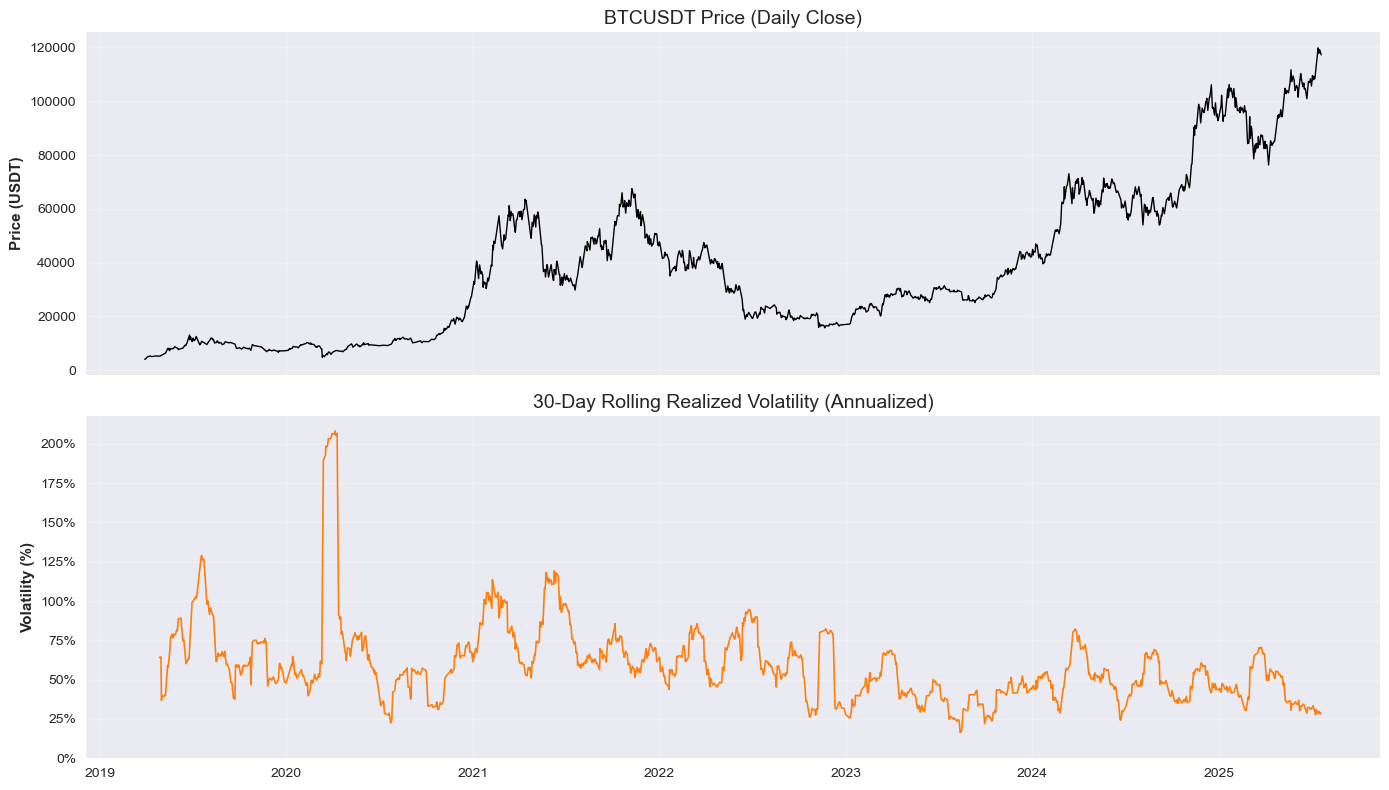

In [285]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1]})

axes[0].plot(daily_df.index, daily_df['close'], color='black', lw=1)
axes[0].set_title("BTCUSDT Price (Daily Close)", fontsize=14)
axes[0].set_ylabel("Price (USDT)")
axes[0].grid(alpha=0.3)

axes[1].plot(daily_df.index, daily_df['rv_est_pct'], color='tab:orange', lw=1.2)
axes[1].set_title("30-Day Rolling Realized Volatility (Annualized)", fontsize=14)
axes[1].set_ylabel("Volatility (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [286]:
print("=== BTCUSDT Price (Daily Close) ===")
print(f"Start date: {daily_df.index.min().date()}")
print(f"End date:   {daily_df.index.max().date()}")
print(f"Number of days: {len(daily_df):,}")
print(f"Min price:  {daily_df['close'].min():,.2f} USDT")
print(f"Max price:  {daily_df['close'].max():,.2f} USDT")
print(f"Mean price: {daily_df['close'].mean():,.2f} USDT")
print(f"Last price: {daily_df['close'].iloc[-1]:,.2f} USDT")

print("\n=== 30-Day Realized Volatility (Annualized, %) ===")
print(f"Window: {window} days")
print(f"Mean vol: {rv_pct.mean():.2f}%")
print(f"Median vol: {rv_pct.median():.2f}%")
print(f"Min vol: {rv_pct.min():.2f}%")
print(f"Max vol: {rv_pct.max():.2f}%")
print(f"Last vol: {rv_pct.iloc[-1]:.2f}%")


=== BTCUSDT Price (Daily Close) ===
Start date: 2019-03-30
End date:   2025-07-20
Number of days: 2,305
Min price:  4,103.95 USDT
Max price:  119,841.18 USDT
Mean price: 38,329.36 USDT
Last price: 117,265.12 USDT

=== 30-Day Realized Volatility (Annualized, %) ===
Window: 30 days
Mean vol: 59.31%
Median vol: 55.16%
Min vol: 16.47%
Max vol: 208.22%
Last vol: 28.37%


### Testing the simple forecasts (Naive & EWMA)

We now test two simple volatility forecasts: **Naive** and **EWMA (RiskMetrics)**. The Naive model is the simplest possible approach, while EWMA adds exponential weighting so that recent returns matter more than older ones. By comparing these forecasts against realized volatility at horizons such as 1, 5, 10, and 30 days, we get a natural baseline that more complex models (e.g., GARCH) should aim to beat.

All series are **annualized and expressed in %** and are **properly aligned** (forecasts at time *t* use only information up to *t* and are compared to realized volatility over *t+1 … t+h*).

**Outputs**
- **Naive forecast:** `naive_h{h}_pct`  
- **EWMA forecast:** `ewma_naive_h1` for 1-day, and `ewma_forecast_h{h}` for h > 1  
- **Realized target:** `realized_h{h}_pct` (volatility that actually occurred over the next h days)

**Evaluation metrics**
- **MAE** → mean absolute error (average size of errors)  
- **RMSE** → root mean squared error (penalizes large errors more)  
- **Bias** → mean error (shows if the model systematically over- or under-forecasts)


In [287]:
# horizons to test
horizons = [1, 2, 10, 30]

# --- build forecasts & realized targets ---
for h in horizons:
    # naive forecast
    daily_df[f'naive_h{h}_pct'] = naive_forecast(daily_df['rv_est_pct'], h=h)
    
    # ewma forecast
    if h == 1:
        daily_df[f'ewma_h{h}_pct'] = daily_df['ewma_vol'].shift(1)
    else:
        daily_df[f'ewma_h{h}_pct'] = daily_df['ewma_vol'].shift(1) * np.sqrt(h)
    
    # realized future volatility target
    daily_df[f'realized_h{h}_pct'] = realized_future_vol(daily_df['log_returns'], h=h, ann=365)

# --- evaluation ---
results = {}

for h in horizons:
    # realized
    t = daily_df[f'realized_h{h}_pct']
    
    for model in ['naive', 'ewma']:
        f = daily_df[f'{model}_h{h}_pct']
        df_eval = pd.concat([f, t], axis=1).dropna()
        err = df_eval[f'{model}_h{h}_pct'] - df_eval[f'realized_h{h}_pct']
        
        results[(model, h)] = {
            "MAE": err.abs().mean(),
            "RMSE": np.sqrt((err**2).mean()),
            "Bias": err.mean()
        }

results_df = pd.DataFrame(results).T.round(2)
print(results_df)


KeyError: 'ewma_vol'

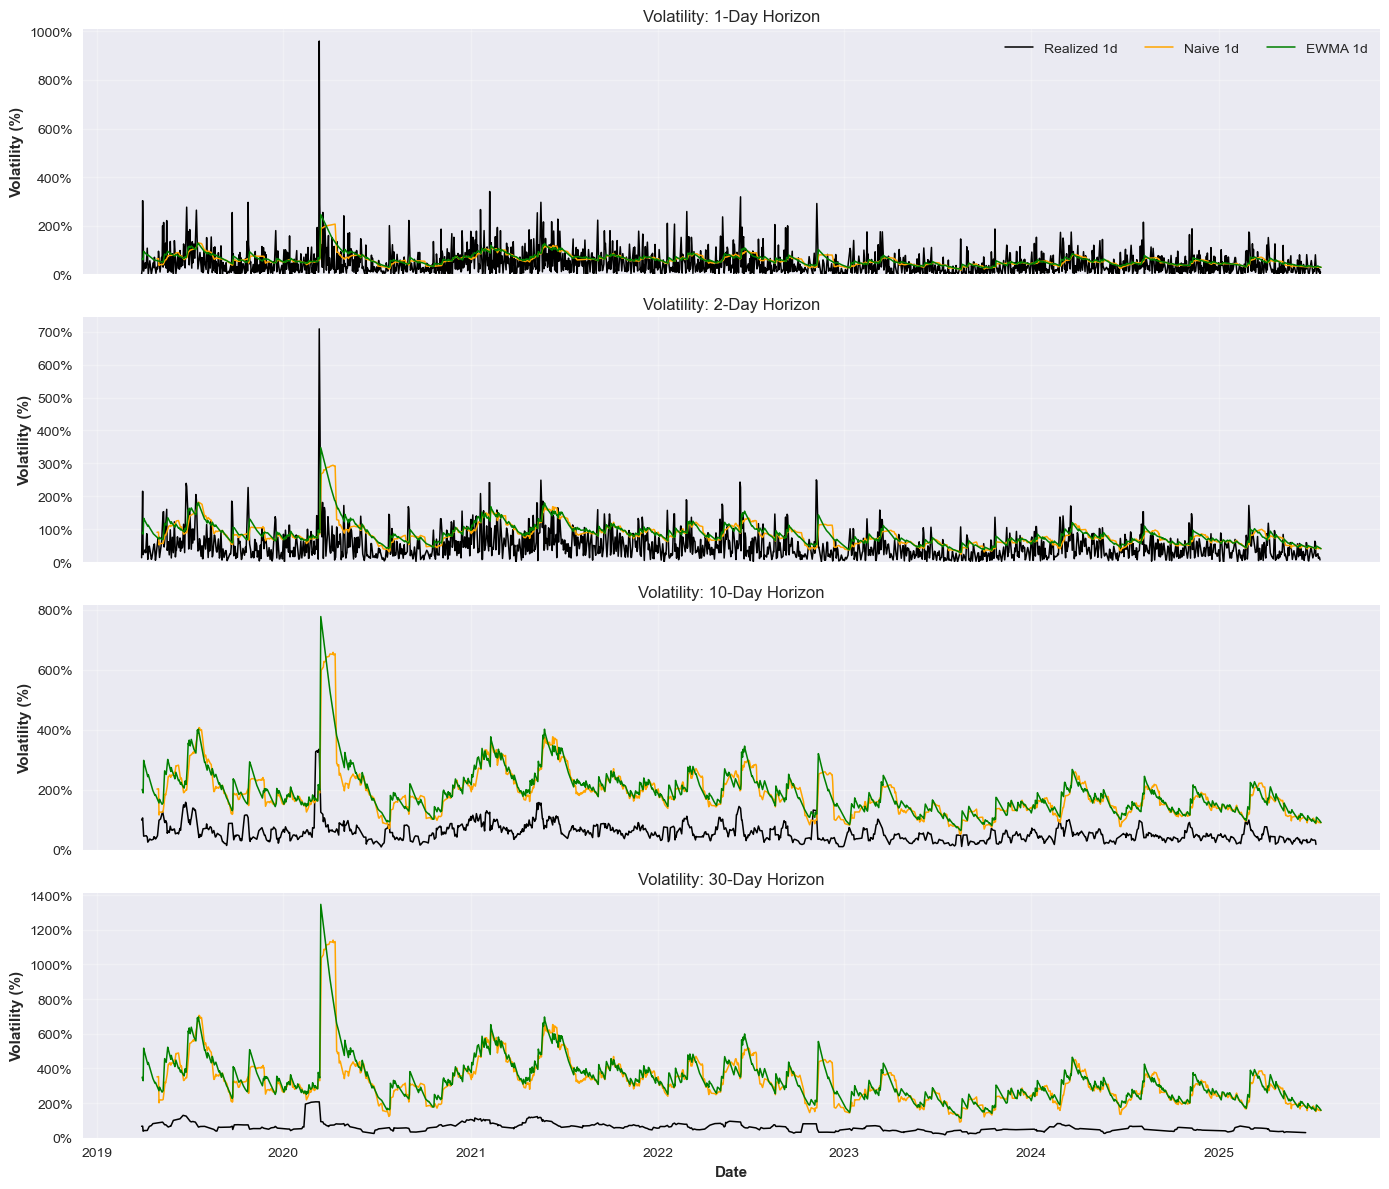

In [ ]:
fig, axes = plt.subplots(len(horizons), 1, figsize=(14, 12), sharex=True)

for i, h in enumerate(horizons):
    ax = axes[i]
    
    # column names
    realized_col = f"realized_h{h}_pct"
    naive_col    = f"naive_h{h}_pct"
    # EWMA naming: h=1 used 'ewma_naive_h1', others 'ewma_forecast_h{h}'
    ewma_col     = "ewma_naive_h1" if h == 1 else f"ewma_forecast_h{h}"
    
    # plot (skip gracefully if a column is missing)
    if realized_col in daily_df:
        ax.plot(daily_df.index, daily_df[realized_col], label=f"Realized {h}d", color="black", lw=1.1)
    if naive_col in daily_df:
        ax.plot(daily_df.index, daily_df[naive_col], label=f"Naive {h}d", color="orange", alpha=1, lw=1.1)
    if ewma_col in daily_df:
        ax.plot(daily_df.index, daily_df[ewma_col], label=f"EWMA {h}d", color="green", alpha=1, lw=1.1)

    ax.set_title(f"Volatility: {h}-Day Horizon")
    ax.set_ylabel("Volatility (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    if i == len(horizons) - 1:
        ax.set_xlabel("Date")
    if i == 0:
        ax.legend(ncol=3)

plt.tight_layout()
plt.show()

We observe that choosing a very short horizon such as 1 or 2 days leads to forecasts that track realized volatility fairly well, but the underlying rolling volatility estimate over such a short window is extremely noisy. This noise makes the forecast unstable and difficult to interpret in practice. On the other hand, when we extend the horizon to longer periods such as 10 or 30 days, the realized volatility measure becomes much smoother and more stable, but the Naive forecast is less accurate because recent short-term changes in volatility are averaged out and not captured quickly enough.
This highlights the classic trade-off in volatility modeling: short horizons give forecasts that are responsive but noisy, while long horizons give forecasts that are stable but sluggish.